# Energy Consumption Comparison: Linux vs Unikernel

This notebook compares the package energy consumption (pkg_joules) between Linux and Unikernel systems across multiple benchmark runs.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn style
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

## 2. Load the CSV Data

In [3]:
# Load Linux data
linux_df = pd.read_csv('linux_first_1.csv')

# Load Unikernel data
unikernel_df = pd.read_csv('unikernel_first_1.csv')

# Display first few rows to verify data
print("Linux data shape:", linux_df.shape)
print("Unikernel data shape:", unikernel_df.shape)
print("\nFirst few rows of Linux data:")
print(linux_df.head())
print("\nFirst few rows of Unikernel data:")
print(unikernel_df.head())

Linux data shape: (30, 12)
Unikernel data shape: (30, 12)

First few rows of Linux data:
   array_size   cpu_cycles   cycles_start     cycles_end       time_ns  \
0      100000  35324612596  2327642331357  2362966943953  1.041290e+10   
1      100000  35321258318  2362968110598  2398289368916  1.041189e+10   
2      100000  35320411159  2398289923279  2433610334438  1.041164e+10   
3      100000  35318108502  2433610881293  2468928989795  1.042478e+10   
4      100000  35321784385  2468929535850  2504251320235  1.072762e+10   

        time_ms  pkg_joules      pkg_mJ  dram_joules  dram_mJ  total_joules  \
0  10412.895387  221.351410  221351.410          NaN      NaN    221.351410   
1  10411.894345  222.436768  222436.768          NaN      NaN    222.436768   
2  10411.635415  222.869324  222869.324          NaN      NaN    222.869324   
3  10424.781997  223.193451  223193.451          NaN      NaN    223.193451   
4  10727.620400  223.597992  223597.992          NaN      NaN    223.59

## 3. Data Preprocessing

Create run numbers for each dataset to use as the x-axis.

In [4]:
# Add run numbers (starting from 1)
linux_df['run'] = range(1, len(linux_df) + 1)
unikernel_df['run'] = range(1, len(unikernel_df) + 1)

# Extract pkg_joules for both datasets
linux_energy = linux_df[['run', 'pkg_joules']].copy()
unikernel_energy = unikernel_df[['run', 'pkg_joules']].copy()

print("Linux energy data:")
print(linux_energy.head())
print("\nUnikernel energy data:")
print(unikernel_energy.head())

Linux energy data:
   run  pkg_joules
0    1  221.351410
1    2  222.436768
2    3  222.869324
3    4  223.193451
4    5  223.597992

Unikernel energy data:
   run  pkg_joules
0    1  199.841339
1    2  199.254837
2    3  198.816665
3    4  198.787628
4    5  198.711975


## 4. Create Line Plot Comparing Energy Consumption

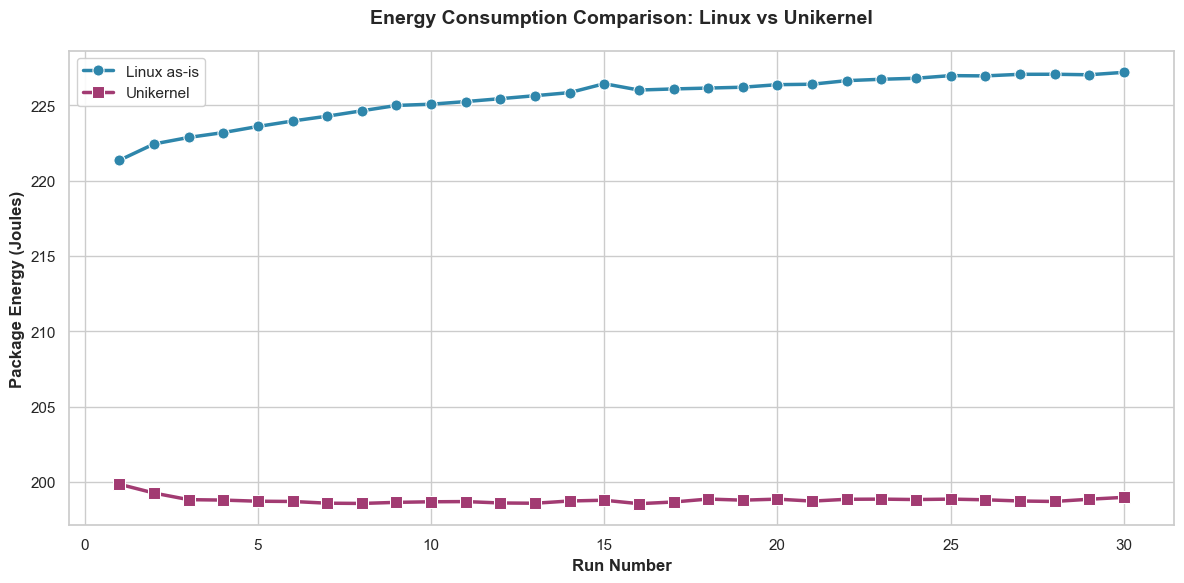


Summary Statistics:

Linux:
  Mean: 225.49 J
  Std:  1.56 J
  Min:  221.35 J
  Max:  227.19 J

Unikernel:
  Mean: 198.79 J
  Std:  0.24 J
  Min:  198.55 J
  Max:  199.84 J

Energy Difference:
  Average Linux - Unikernel: 26.70 J
  Percentage: 13.43%


In [13]:
# Create figure and axis
plt.figure(figsize=(12, 6))

# Plot using seaborn
sns.lineplot(data=linux_energy, x='run', y='pkg_joules', 
             marker='o', linewidth=2.5, markersize=8,
             label='Linux as-is', color='#2E86AB')

sns.lineplot(data=unikernel_energy, x='run', y='pkg_joules', 
             marker='s', linewidth=2.5, markersize=8,
             label='Unikernel', color='#A23B72')

# Add labels and title
plt.xlabel('Run Number', fontsize=12, fontweight='bold')
plt.ylabel('Package Energy (Joules)', fontsize=12, fontweight='bold')
plt.title('Energy Consumption Comparison: Linux vs Unikernel', 
          fontsize=14, fontweight='bold', pad=20)

# Set y-axis to start from 0 to show full scale
# plt.ylim(0, None)

# Add legend
plt.legend(fontsize=11, loc='best', framealpha=0.9)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"\nLinux:")
print(f"  Mean: {linux_energy['pkg_joules'].mean():.2f} J")
print(f"  Std:  {linux_energy['pkg_joules'].std():.2f} J")
print(f"  Min:  {linux_energy['pkg_joules'].min():.2f} J")
print(f"  Max:  {linux_energy['pkg_joules'].max():.2f} J")

print(f"\nUnikernel:")
print(f"  Mean: {unikernel_energy['pkg_joules'].mean():.2f} J")
print(f"  Std:  {unikernel_energy['pkg_joules'].std():.2f} J")
print(f"  Min:  {unikernel_energy['pkg_joules'].min():.2f} J")
print(f"  Max:  {unikernel_energy['pkg_joules'].max():.2f} J")

print(f"\nEnergy Difference:")
print(f"  Average Linux - Unikernel: {linux_energy['pkg_joules'].mean() - unikernel_energy['pkg_joules'].mean():.2f} J")
print(f"  Percentage: {((linux_energy['pkg_joules'].mean() / unikernel_energy['pkg_joules'].mean()) - 1) * 100:.2f}%")

## 5. Cumulative Distribution Function (CDF)

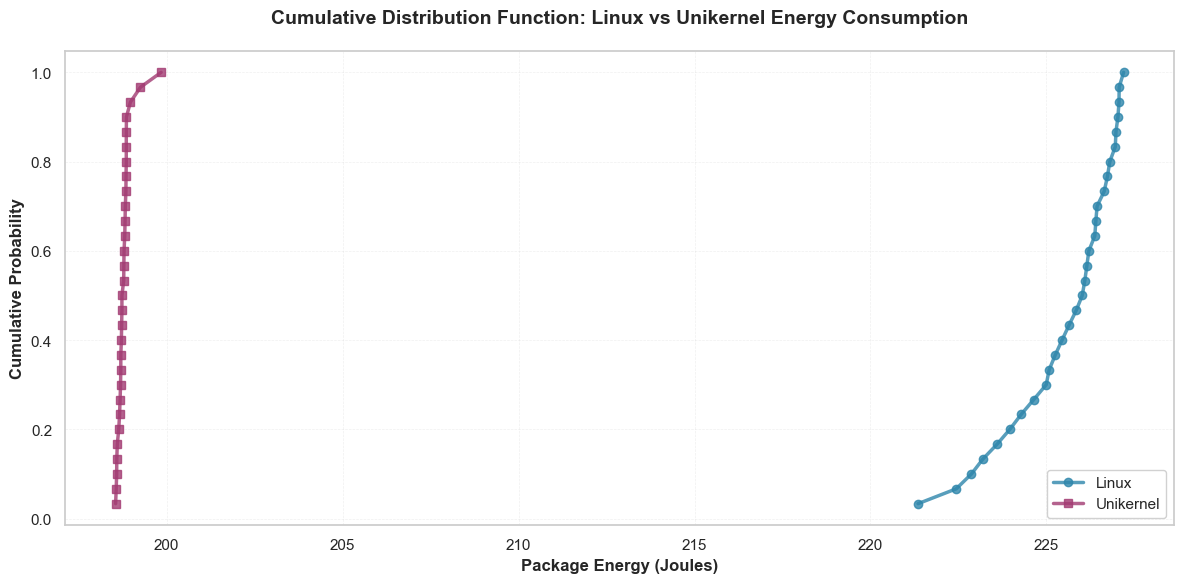

In [14]:
# Create figure for CDF
plt.figure(figsize=(12, 6))

# Sort the data for CDF
linux_sorted = np.sort(linux_energy['pkg_joules'])
unikernel_sorted = np.sort(unikernel_energy['pkg_joules'])

# Calculate cumulative probabilities
linux_cdf = np.arange(1, len(linux_sorted) + 1) / len(linux_sorted)
unikernel_cdf = np.arange(1, len(unikernel_sorted) + 1) / len(unikernel_sorted)

# Plot CDF
plt.plot(linux_sorted, linux_cdf, marker='o', linewidth=2.5, markersize=6,
         label='Linux', color='#2E86AB', alpha=0.8)
plt.plot(unikernel_sorted, unikernel_cdf, marker='s', linewidth=2.5, markersize=6,
         label='Unikernel', color='#A23B72', alpha=0.8)

# Add labels and title
plt.xlabel('Package Energy (Joules)', fontsize=12, fontweight='bold')
plt.ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
plt.title('Cumulative Distribution Function: Linux vs Unikernel Energy Consumption', 
          fontsize=14, fontweight='bold', pad=20)

# Add legend and grid
plt.legend(fontsize=11, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

## 6. Box Plot Comparison

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_56651/2515065970.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_data, x='System', y='Energy (Joules)',


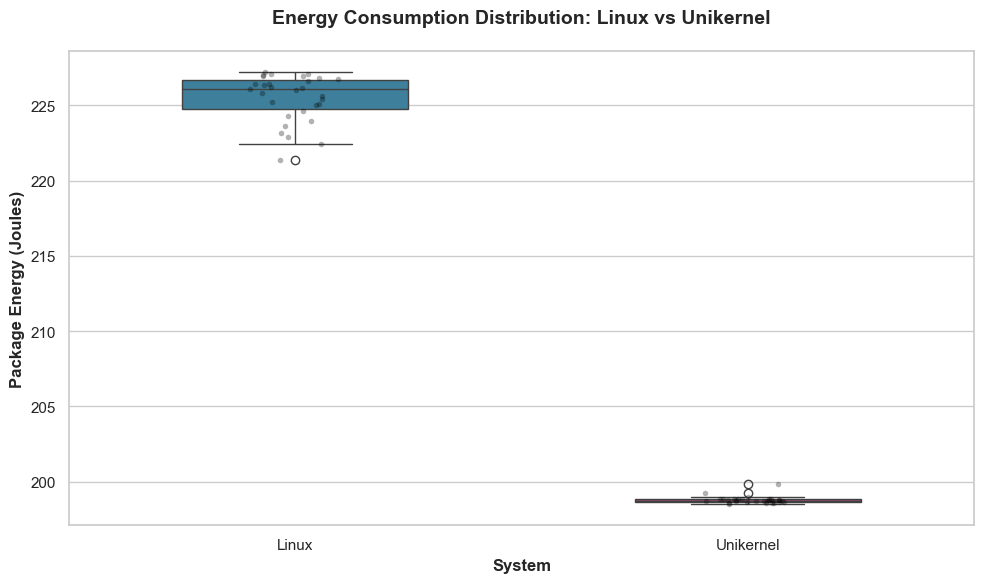


Quartile Information:

Linux:
  Q1 (25%): 224.73 J
  Median (50%): 226.05 J
  Q3 (75%): 226.71 J
  IQR: 1.98 J

Unikernel:
  Q1 (25%): 198.68 J
  Median (50%): 198.75 J
  Q3 (75%): 198.84 J
  IQR: 0.16 J


In [15]:
# Combine data for boxplot
combined_data = pd.DataFrame({
    'System': ['Linux'] * len(linux_energy) + ['Unikernel'] * len(unikernel_energy),
    'Energy (Joules)': pd.concat([linux_energy['pkg_joules'], unikernel_energy['pkg_joules']]).values
})

# Create figure for boxplot
plt.figure(figsize=(10, 6))

# Create boxplot using seaborn
sns.boxplot(data=combined_data, x='System', y='Energy (Joules)', 
            palette={'Linux': '#2E86AB', 'Unikernel': '#A23B72'},
            width=0.5)

# Add individual data points
sns.stripplot(data=combined_data, x='System', y='Energy (Joules)', 
              color='black', alpha=0.3, size=4)

# Add labels and title
plt.ylabel('Package Energy (Joules)', fontsize=12, fontweight='bold')
plt.xlabel('System', fontsize=12, fontweight='bold')
plt.title('Energy Consumption Distribution: Linux vs Unikernel', 
          fontsize=14, fontweight='bold', pad=20)

# # Set y-axis to start from 0
# plt.ylim(0, None)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

# Print quartile information
print("\nQuartile Information:")
print(f"\nLinux:")
print(f"  Q1 (25%): {linux_energy['pkg_joules'].quantile(0.25):.2f} J")
print(f"  Median (50%): {linux_energy['pkg_joules'].quantile(0.50):.2f} J")
print(f"  Q3 (75%): {linux_energy['pkg_joules'].quantile(0.75):.2f} J")
print(f"  IQR: {linux_energy['pkg_joules'].quantile(0.75) - linux_energy['pkg_joules'].quantile(0.25):.2f} J")

print(f"\nUnikernel:")
print(f"  Q1 (25%): {unikernel_energy['pkg_joules'].quantile(0.25):.2f} J")
print(f"  Median (50%): {unikernel_energy['pkg_joules'].quantile(0.50):.2f} J")
print(f"  Q3 (75%): {unikernel_energy['pkg_joules'].quantile(0.75):.2f} J")
print(f"  IQR: {unikernel_energy['pkg_joules'].quantile(0.75) - unikernel_energy['pkg_joules'].quantile(0.25):.2f} J")

In [16]:
## 7. Comparison with Different CPU Governors

In [17]:
# Load new data files
linux_2_df = pd.read_csv('linux_2_1.csv')
linux_schedutil_df = pd.read_csv('linux_schedutil_2_1.csv')
unikernel_2_df = pd.read_csv('unikernel_2_1.csv')

# Add run numbers
linux_2_df['run'] = range(1, len(linux_2_df) + 1)
linux_schedutil_df['run'] = range(1, len(linux_schedutil_df) + 1)
unikernel_2_df['run'] = range(1, len(unikernel_2_df) + 1)

print("Data loaded successfully:")
print(f"Linux (default): {linux_2_df.shape}")
print(f"Linux (schedutil): {linux_schedutil_df.shape}")
print(f"Unikernel: {unikernel_2_df.shape}")

Data loaded successfully:
Linux (default): (30, 13)
Linux (schedutil): (30, 13)
Unikernel: (30, 13)


### 7.1 Energy Consumption Comparison (Three Systems)

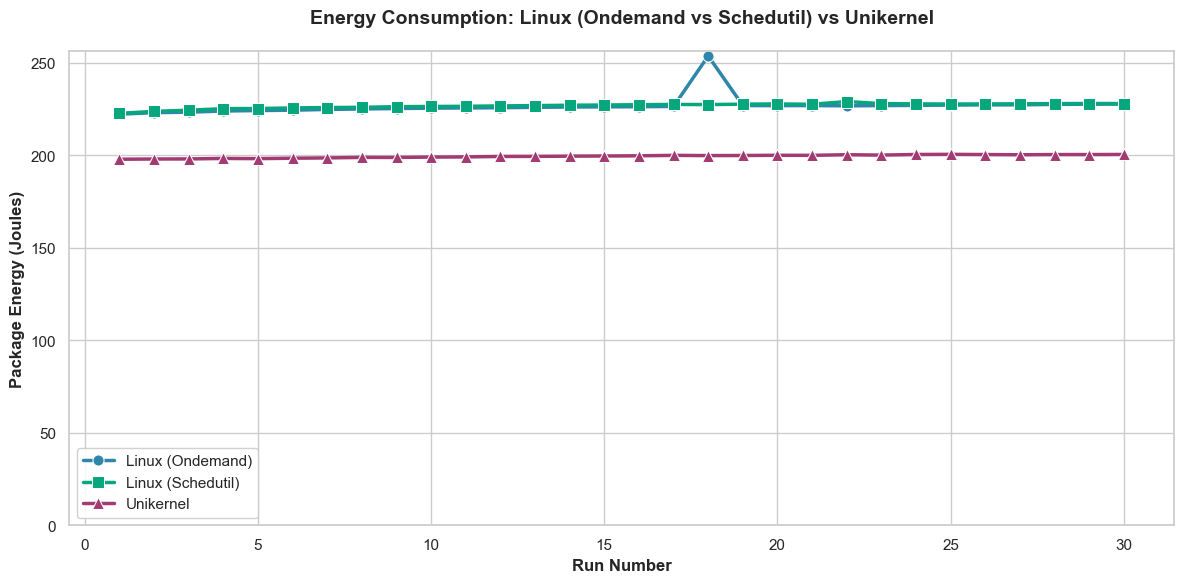


Summary Statistics:

Linux (Ondemand):
  Mean: 226.80 J
  Std:  5.29 J
  Min:  222.26 J
  Max:  253.74 J

Linux (Schedutil):
  Mean: 226.78 J
  Std:  1.42 J
  Min:  222.69 J
  Max:  229.07 J

Unikernel:
  Mean: 199.48 J
  Std:  0.86 J
  Min:  197.90 J
  Max:  200.52 J


In [18]:
# Create figure and axis
plt.figure(figsize=(12, 6))

# Plot all three systems
sns.lineplot(data=linux_2_df, x='run', y='pkg_joules', 
             marker='o', linewidth=2.5, markersize=8,
             label='Linux (Ondemand)', color='#2E86AB')

sns.lineplot(data=linux_schedutil_df, x='run', y='pkg_joules', 
             marker='s', linewidth=2.5, markersize=8,
             label='Linux (Schedutil)', color='#06A77D')

sns.lineplot(data=unikernel_2_df, x='run', y='pkg_joules', 
             marker='^', linewidth=2.5, markersize=8,
             label='Unikernel', color='#A23B72')

# Add labels and title
plt.xlabel('Run Number', fontsize=12, fontweight='bold')
plt.ylabel('Package Energy (Joules)', fontsize=12, fontweight='bold')
plt.title('Energy Consumption: Linux (Ondemand vs Schedutil) vs Unikernel', 
          fontsize=14, fontweight='bold', pad=20)

# Set y-axis to start from 0 to show full scale
plt.ylim(0, None)

# Add legend
plt.legend(fontsize=11, loc='best', framealpha=0.9)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"\nLinux (Ondemand):")
print(f"  Mean: {linux_2_df['pkg_joules'].mean():.2f} J")
print(f"  Std:  {linux_2_df['pkg_joules'].std():.2f} J")
print(f"  Min:  {linux_2_df['pkg_joules'].min():.2f} J")
print(f"  Max:  {linux_2_df['pkg_joules'].max():.2f} J")

print(f"\nLinux (Schedutil):")
print(f"  Mean: {linux_schedutil_df['pkg_joules'].mean():.2f} J")
print(f"  Std:  {linux_schedutil_df['pkg_joules'].std():.2f} J")
print(f"  Min:  {linux_schedutil_df['pkg_joules'].min():.2f} J")
print(f"  Max:  {linux_schedutil_df['pkg_joules'].max():.2f} J")

print(f"\nUnikernel:")
print(f"  Mean: {unikernel_2_df['pkg_joules'].mean():.2f} J")
print(f"  Std:  {unikernel_2_df['pkg_joules'].std():.2f} J")
print(f"  Min:  {unikernel_2_df['pkg_joules'].min():.2f} J")
print(f"  Max:  {unikernel_2_df['pkg_joules'].max():.2f} J")

### 7.2 Box Plot Comparison (Three Systems)

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_56651/1887111204.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_data_3, x='System', y='Energy (Joules)',


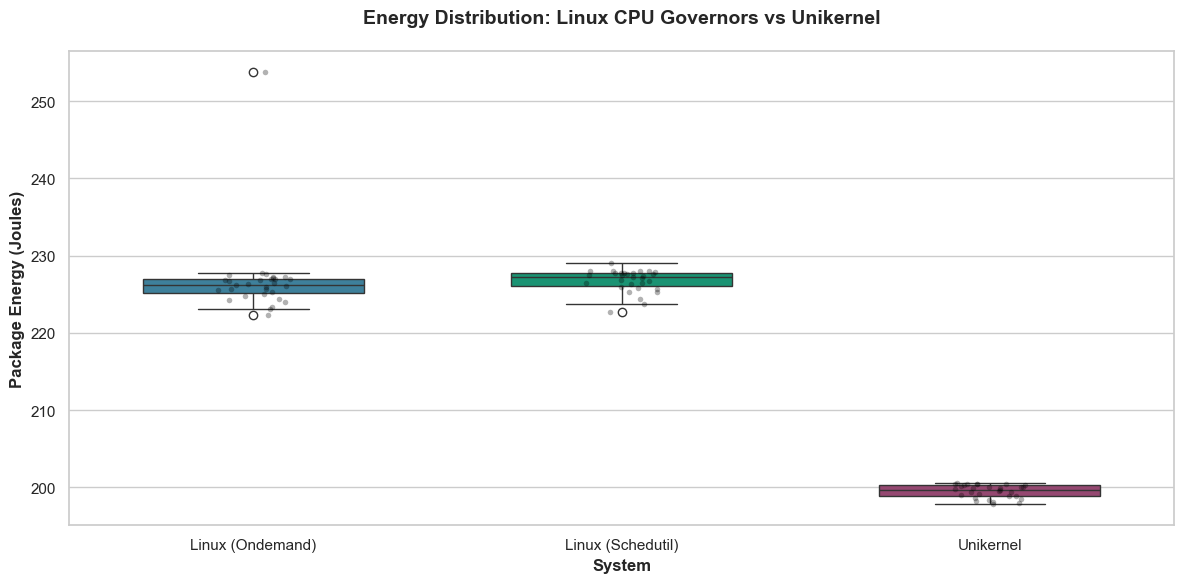

In [19]:
# Combine data for boxplot
combined_data_3 = pd.DataFrame({
    'System': (['Linux (Ondemand)'] * len(linux_2_df) + 
               ['Linux (Schedutil)'] * len(linux_schedutil_df) + 
               ['Unikernel'] * len(unikernel_2_df)),
    'Energy (Joules)': pd.concat([
        linux_2_df['pkg_joules'], 
        linux_schedutil_df['pkg_joules'], 
        unikernel_2_df['pkg_joules']
    ]).values
})

# Create figure for boxplot
plt.figure(figsize=(12, 6))

# Create boxplot using seaborn
sns.boxplot(data=combined_data_3, x='System', y='Energy (Joules)', 
            palette={'Linux (Ondemand)': '#2E86AB', 
                    'Linux (Schedutil)': '#06A77D', 
                    'Unikernel': '#A23B72'},
            width=0.6)

# Add individual data points
sns.stripplot(data=combined_data_3, x='System', y='Energy (Joules)', 
              color='black', alpha=0.3, size=4)

# Add labels and title
plt.ylabel('Package Energy (Joules)', fontsize=12, fontweight='bold')
plt.xlabel('System', fontsize=12, fontweight='bold')
plt.title('Energy Distribution: Linux CPU Governors vs Unikernel', 
          fontsize=14, fontweight='bold', pad=20)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

### 7.3 Running Time Comparison (Three Systems)

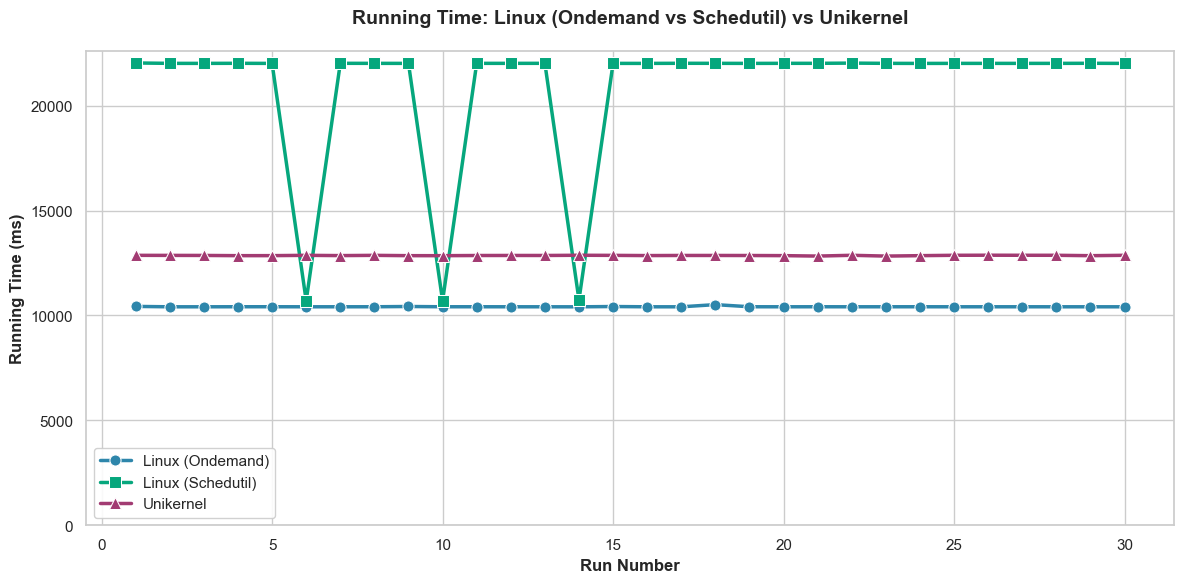


Running Time Statistics:

Linux (Ondemand):
  Mean: 10417.67 ms
  Std:  18.95 ms

Linux (Schedutil):
  Mean: 20885.84 ms
  Std:  3449.34 ms

Unikernel:
  Mean: 12856.98 ms
  Std:  10.36 ms


In [20]:
# Create figure and axis
plt.figure(figsize=(12, 6))

# Plot all three systems
sns.lineplot(data=linux_2_df, x='run', y='time_ms', 
             marker='o', linewidth=2.5, markersize=8,
             label='Linux (Ondemand)', color='#2E86AB')

sns.lineplot(data=linux_schedutil_df, x='run', y='time_ms', 
             marker='s', linewidth=2.5, markersize=8,
             label='Linux (Schedutil)', color='#06A77D')

sns.lineplot(data=unikernel_2_df, x='run', y='time_ms', 
             marker='^', linewidth=2.5, markersize=8,
             label='Unikernel', color='#A23B72')

# Add labels and title
plt.xlabel('Run Number', fontsize=12, fontweight='bold')
plt.ylabel('Running Time (ms)', fontsize=12, fontweight='bold')
plt.title('Running Time: Linux (Ondemand vs Schedutil) vs Unikernel', 
          fontsize=14, fontweight='bold', pad=20)

# Set y-axis to start from 0 to show full scale
plt.ylim(0, None)

# Add legend
plt.legend(fontsize=11, loc='best', framealpha=0.9)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

# Print summary statistics
print("\nRunning Time Statistics:")
print(f"\nLinux (Ondemand):")
print(f"  Mean: {linux_2_df['time_ms'].mean():.2f} ms")
print(f"  Std:  {linux_2_df['time_ms'].std():.2f} ms")

print(f"\nLinux (Schedutil):")
print(f"  Mean: {linux_schedutil_df['time_ms'].mean():.2f} ms")
print(f"  Std:  {linux_schedutil_df['time_ms'].std():.2f} ms")

print(f"\nUnikernel:")
print(f"  Mean: {unikernel_2_df['time_ms'].mean():.2f} ms")
print(f"  Std:  {unikernel_2_df['time_ms'].std():.2f} ms")